# **Carga de datos**

Para este entrenamiento utilizaré un dataset de imágenes de retinografías para detectar el porcentaje de glaucoma. Para ello, he dividido los datos de la siguiente manera:

* **70%** para el entrenamiento
* **10%** para la validación
* **20%** para los tests

In [59]:
import os

raiz = 'Ojos'

# Datos de entrenamiento
train_dir = os.path.join(raiz, 'train')
train_dir_normal = os.path.join(train_dir, 'Normales')
train_dir_glaucoma = os.path.join(train_dir, 'Glaucomas')

# Datos de validación
val_dir = os.path.join(raiz, 'val')
val_dir_normal = os.path.join(val_dir, 'Normales')
val_dir_glaucoma = os.path.join(val_dir, 'Glaucomas')

# Datos de prueba
test_dir = os.path.join(raiz, 'test')
test_dir_normal = os.path.join(test_dir, 'Normales')
test_dir_glaucoma = os.path.join(test_dir, 'Glaucomas')

In [60]:
# Muestro la cantidad de imágenes en cada conjunto
suma_entrenamiento = len(os.listdir(train_dir_normal)) + len(os.listdir(train_dir_glaucoma))
suma_validacion = len(os.listdir(val_dir_normal)) + len(os.listdir(val_dir_glaucoma))
suma_prueba = len(os.listdir(test_dir_normal)) + len(os.listdir(test_dir_glaucoma))

print("Datos de entrenamiento:", suma_entrenamiento, "--- Normales:", len(os.listdir(train_dir_normal)), "--- Glaucoma:", len(os.listdir(train_dir_glaucoma)))
print("Datos de validación:", suma_validacion, "--- Normales:", len(os.listdir(val_dir_normal)), "--- Glaucoma:", len(os.listdir(val_dir_glaucoma)))
print("Datos de prueba:", suma_prueba, "--- Normales:", len(os.listdir(test_dir_normal)), "--- Glaucoma:", len(os.listdir(test_dir_glaucoma)))

Datos de entrenamiento: 339 --- Normales: 219 --- Glaucoma: 120
Datos de validación: 48 --- Normales: 31 --- Glaucoma: 17
Datos de prueba: 98 --- Normales: 63 --- Glaucoma: 35


# **Data Augmentation**

Para esta parte, voy a normalizar las imágenes y a hacer uso de la herramienta ImageDataGenerator del módulo *tensorflow.keras.preprocessing.image* para adaptar las imágenes a la red neuronal que voy a utilizar.

In [69]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import preprocess_input


train_generator = ImageDataGenerator(rescale=1./255,
                                     preprocessing_function=preprocess_input,
                                     rotation_range=20,      # Rota la imagen hasta 20 grados
                                     width_shift_range=0.1,  # Mueve la imagen a los lados
                                     height_shift_range=0.1, # Mueve la imagen arriba/abajo
                                     zoom_range=0.2,         # Aplica un 20% de zoom aleatorio
                                     horizontal_flip=True    # Efecto espejo
)
val_generator = ImageDataGenerator(rescale=1./255)
test_generator = ImageDataGenerator(rescale=1./255)

In [70]:
train_generator = train_generator.flow_from_directory(train_dir,
                                    target_size=(224, 224),
                                    class_mode='categorical',
                                    batch_size=16)

val_generator = val_generator.flow_from_directory(val_dir,
                                  target_size=(224, 224),
                                  class_mode='categorical',
                                  batch_size=16)

test_generator = test_generator.flow_from_directory(test_dir,
                                   target_size=(224, 224),
                                   class_mode='categorical',
                                   batch_size=16)

Found 339 images belonging to 2 classes.
Found 48 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


# **Obtención del modelo (VGG19)**

Ya cargado y normalizado los datos previamente, ahora voy a descargar el modelo VGG19 para utilizarlo para mi entrenamiento y prueba, las imágenes ya han sido adaptadas a este modelo por lo que no hace falta modificar nada más de las mismas.

In [71]:
from tensorflow.keras.applications import VGG19

base_model = VGG19(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

# Congelo las capas que son convolucionales
for layer in base_model.layers:
  layer.trainable = False
  
base_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

Para aplicar el fine-tuning, primero he eliminado las capas densa del modelo base para agregar las mías propias, para las capas densas voy a utilizar **4096** neuronas y función de activación tanto relu cómo softmax, y también una capa *Flatten* y *Dropout*. Esto se hace de la siguiente manera:

In [75]:
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import Sequential

model = Sequential()

model.add(base_model) # Agrego el modelo base
model.add(Flatten()) # Aplanar la salida del modelo base
model.add(Dense(4096, activation='relu')) # Capa densa con 4096 neuronas y activación ReLU
model.add(Dense(4096, activation='relu')) # Otra capa densa con 4096 neuronas y activación ReLU
model.add(Dropout(0.5)) # Capa de Dropout para reducir el sobreajuste
model.add(Dense(2, activation='softmax')) # Capa de salida con 2 neuronas (Normales y Glaucoma) y activación softmax

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,578,434 (532.45 MB)

 Trainable params: 119,554,050 (456.06 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

# **Entrenamiento del modelo**

Ahora entreno el modelo con los siguientes parámetros:

* loss = **categorical_crossentropy**
* optimizer = **Adam** con un learning rate de **1e-4**
* metrics = **accuracy**

Aparte, para una buena praćtica me guardo el modelo de mejor validación.

In [79]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_name = 'modelo_glaucoma.h5'

# Configuro el callback para quedarme con el mejor modelo
checkpoint = ModelCheckpoint(model_name,
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

# Entrenamiento del modelo
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

model.fit(train_generator,
          epochs=25,
          validation_data=val_generator,
          steps_per_epoch=steps_per_epoch,
          validation_steps=validation_steps,
          callbacks=[checkpoint])

Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5759 - loss: 1.1056
Epoch 1: val_accuracy improved from None to 0.58333, saving model to modelo_glaucoma.h5



Epoch 1: finished saving model to modelo_glaucoma.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5728 - loss: 0.9641 - val_accuracy: 0.5833 - val_loss: 0.6700
Epoch 2/25
 1/21 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6250 - loss: 0.6444
Epoch 2: val_accuracy improved from 0.58333 to 0.60417, saving model to modelo_glaucoma.h5



Epoch 2: finished saving model to modelo_glaucoma.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.6250 - loss: 0.6444 - val_accuracy: 0.6042 - val_loss: 0.6372
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5831 - loss: 0.8115
Epoch 3: val_accuracy improved from 0.60417 to 0.62500, saving model to modelo_glaucoma.h5



Epoch 3: finished saving model to modelo_glaucoma.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6161 - loss: 0.8381 - val_accuracy: 0.6250 - val_loss: 0.6552
Epoch 4/25
 1/21 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.6875 - loss: 0.6304
Epoch 4: val_accuracy did not improve from 0.62500
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.6875 - loss: 0.6304 - val_accuracy: 0.5833 - val_loss: 0.6865
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6931 - loss: 0.6477
Epoch 5: val_accuracy did not improve from 0.62500
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6842 - loss: 0.6761 - val_accuracy: 0.3750 - val_loss: 1.1927
Epoch 6/25
 1/21 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6875 - loss: 0.5617
Epoch 6: val_accuracy did not improve from 0.62500
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.6875 - loss: 0.5617 - val_accuracy: 0.3750 - val_loss: 1.1206
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6437 - loss: 0.


Epoch 7: finished saving model to modelo_glaucoma.h5
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6518 - loss: 0.7108 - val_accuracy: 0.6458 - val_loss: 0.6857
Epoch 8/25
 1/21 ━━━━━━━━━━━━━━━━━━━━ 13s 667ms/step - accuracy: 1.0000 - loss: 0.0764
Epoch 8: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 1.0000 - loss: 0.0764 - val_accuracy: 0.6458 - val_loss: 0.7914
Epoch 9/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6432 - loss: 0.6850
Epoch 9: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6811 - loss: 0.6164 - val_accuracy: 0.5833 - val_loss: 0.7034
Epoch 10/25
 1/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9375 - loss: 0.4024
Epoch 10: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.9375 - loss: 0.4024 - val_accuracy: 0.5417 - val_loss: 0.6725
Epoch 11/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7419 - lo

# **Prueba del modelo**

Una vez con el modelo ya entrenado, cargo los pesos del mejor modelo según el callback establecido anteriormente y cuando termine de cargar, realizo una evaluación del modelo con los datos de prueba.

In [80]:
model.load_weights(model_name)

loss, acc = model.evaluate(test_generator)
print("test accuracy:", round(acc, 4))
print("test loss:", round(loss, 4))

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6837 - loss: 0.6169
test accuracy: 0.6837
test loss: 0.6169


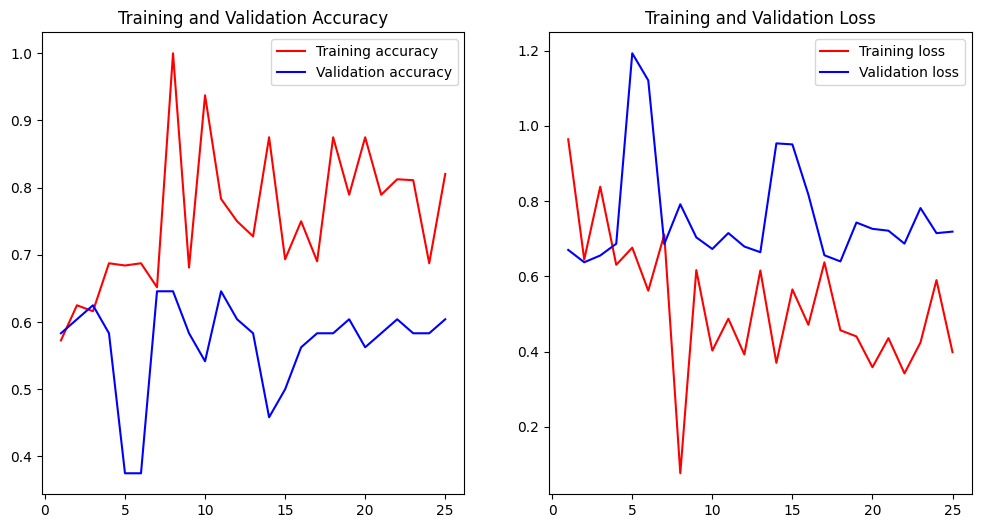

In [82]:
# Muestro las gráficas de entrenamiento
import matplotlib.pyplot as plt

# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

# **Deep-Tuning**

Con la técnica de *fine-tuning* se pudo ver que conseguí que el modelo tuviese un 69% de acierto, ahora teniendo en cuenta ese mejor modelo, vamos a hacer que todas las capas del mismo sean entrenables y vamos a volver a entrenarlo con los mismos parámnetros.

In [83]:
model.load_weights('modelo_glaucoma.h5')

model.trainable = True # Descongelo todas las capas para el deep-tuning

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator,
          epochs=50,
          validation_data=val_generator,
          steps_per_epoch=steps_per_epoch,
          validation_steps=validation_steps,
          batch_size=8,
          callbacks=[checkpoint])

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6741 - loss: 0.6581
Epoch 1: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6749 - loss: 0.6462 - val_accuracy: 0.6042 - val_loss: 0.6414
Epoch 2/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8125 - loss: 0.5662

/home/frannalpes/Escritorio/TFG/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.8125 - loss: 0.5662 - val_accuracy: 0.6042 - val_loss: 0.6415
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7251 - loss: 0.5497
Epoch 3: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7430 - loss: 0.5370 - val_accuracy: 0.5208 - val_loss: 0.6548
Epoch 4/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5625 - loss: 0.6803
Epoch 4: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.5625 - loss: 0.6803 - val_accuracy: 0.5208 - val_loss: 0.6550
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7525 - loss: 0.5268
Epoch 5: val_accuracy did not improve from 0.64583
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7368 - loss: 0.5483 - val_accuracy: 0.5208 - val_loss: 0.6548
Epoch 6/50
 1/21 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.7500 - loss: 0.69

In [84]:
model.load_weights(model_name)

loss, acc = model.evaluate(test_generator)
print("test accuracy:", round(acc, 4))
print("test loss:", round(loss, 4))

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6837 - loss: 0.6169
test accuracy: 0.6837
test loss: 0.6169


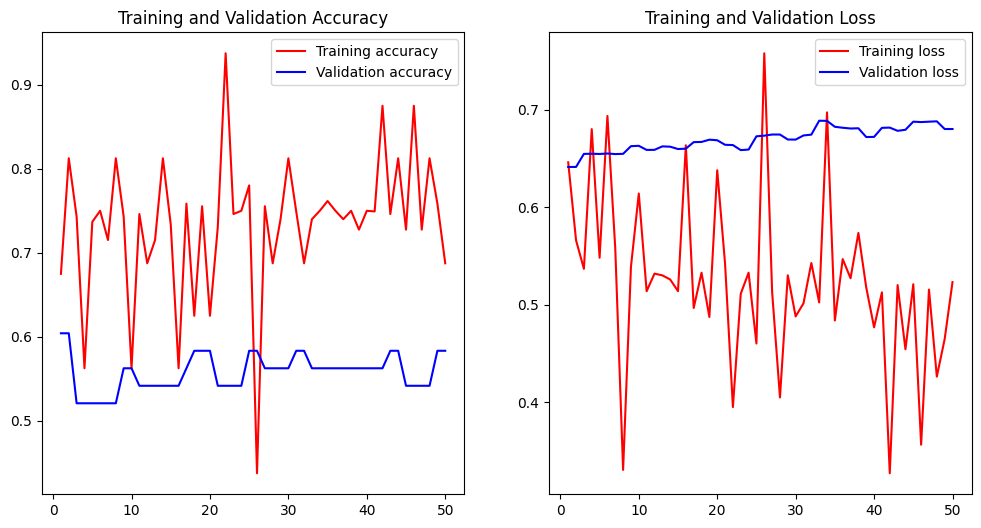

In [85]:
# Gráficos de entrenamiento
acc = model.history.history['accuracy']
val_acc = model.history.history['val_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()